# Notebook 04: Transformer Block

## Overview

- **Duration**: ~2 hours
- **Prerequisites**: Notebooks 01-03
- **Learning Objectives**:
  1. Understand residual connections and their importance
  2. Implement Layer Normalization from scratch
  3. Implement the feed-forward network (MLP)
  4. Assemble a complete transformer block

## Introduction

A transformer block combines:
1. **Multi-head attention** (from Notebook 03)
2. **Feed-forward network** (MLP)
3. **Layer normalization**
4. **Residual connections**

### GPT Architecture (Pre-norm)

```
x -> LayerNorm -> Attention -> + -> LayerNorm -> FFN -> + -> output
    \_________________________|______________________|  
         (residual)                  (residual)
```

In [1]:
import sys
sys.path.insert(0, '../..')

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

## Exercise 4.1: Layer Normalization (30 min)

Layer Normalization normalizes across the feature dimension (not batch):

$$\text{LayerNorm}(x) = \gamma \cdot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

Where μ and σ² are computed per-sample across features.

In [2]:
####solution 4.1
class LayerNorm(nn.Module):
    """
    Layer Normalization with learnable parameters.
    
    Args:
        ndim: Dimension to normalize over (last dim)
        bias: Whether to include bias parameter
        eps: Small constant for numerical stability
    """
    
    def __init__(self, ndim: int, bias: bool = True, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        
        # TODO: Create learnable parameters
        # self.weight (gamma): scale parameter, shape (ndim,), initialized to 1
        self.weight = nn.Parameter(torch.ones(ndim))
        # self.bias (beta): shift parameter, shape (ndim,), initialized to 0 (if bias=True)
        if bias:
            self.bias = nn.Parameter(torch.zeros(ndim))
        else:
            self.register_parameter('bias', None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input of shape (..., ndim)
            
        Returns:
            Normalized output of same shape
        """
        # TODO: Implement layer normalization
        # 1. Compute mean across last dimension
        mean = x.mean(dim=-1, keepdim=True)
        # 2. Compute variance across last dimension
        var = x.var(dim=-1, keepdim=True)
        # 3. Normalize: (x - mean) / sqrt(var + eps)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        # 4. Scale and shift: weight * normalized + bias
        if self.bias is not None:
            output = self.weight * normalized + self.bias
        else:
            output = self.weight * normalized

        return output

In [7]:
####test cell
# Test Layer Normalization
ln = LayerNorm(64)
x = torch.randn(2, 10, 64)
output = ln(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Check that output has ~0 mean and ~1 std per sample
print(f"\nOutput mean (should be ~0): {output.mean(dim=-1).mean():.4f}")
print(f"Output std (should be ~1): {output.std(dim=-1).mean():.4f}")

# Compare with PyTorch's LayerNorm
pytorch_ln = nn.LayerNorm(64)
pytorch_output = pytorch_ln(x)

# They should be similar (not identical due to different weight init)
print(f"\nOur output range: [{output.min():.3f}, {output.max():.3f}]")
print(f"PyTorch output range: [{pytorch_output.min():.3f}, {pytorch_output.max():.3f}]")

assert output.shape == x.shape
print("\n✓ Exercise 4.1 passed!")

Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])

Output mean (should be ~0): -0.0000
Output std (should be ~1): 1.0000

Our output range: [-3.120, 2.994]
PyTorch output range: [-3.145, 3.018]

✓ Exercise 4.1 passed!


## Exercise 4.2: Feed-Forward Network (20 min)

The FFN is a simple two-layer MLP with a non-linearity:

$$\text{FFN}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$

The hidden dimension is typically 4x the model dimension.

In [4]:
####solution 4.2
class FeedForward(nn.Module):
    """
    Feed-forward network with GELU activation.
    
    Args:
        d_model: Input/output dimension
        d_ff: Hidden dimension (typically 4 * d_model)
        dropout: Dropout probability
        bias: Whether to use bias in linear layers
    """
    
    def __init__(
        self,
        d_model: int,
        d_ff: int = None,
        dropout: float = 0.1,
        bias: bool = True,
    ):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        # TODO: Create the feed-forward network
        # self.fc1: Linear layer d_model -> d_ff
        self.fc1 = nn.Linear(d_model, d_ff, bias=bias)
        # self.fc2: Linear layer d_ff -> d_model
        self.fc2 = nn.Linear(d_ff, d_model, bias=bias)
        # self.dropout: Dropout layer
        self.dropout = nn.Dropout(dropout)
        # self.dropout: Dropout layer
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input of shape (batch, seq_len, d_model)
            
        Returns:
            Output of shape (batch, seq_len, d_model)
        """
        # TODO: Implement: fc2(dropout(gelu(fc1(x))))
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

In [9]:
####test cell
# Test FFN
ffn = FeedForward(64, dropout=0.0)
x = torch.randn(2, 10, 64)
output = ffn(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Hidden dimension: {4 * 64}")

assert output.shape == x.shape
print("\n✓ Exercise 4.2 passed!")

Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])
Hidden dimension: 256

✓ Exercise 4.2 passed!


## Exercise 4.3: Complete Transformer Block (30 min)

Now combine everything into a transformer block.

In [5]:
# Import MultiHeadAttention from previous notebook or shared module
try:
    from shared.model import CausalSelfAttention as MultiHeadAttention
    print("Using MultiHeadAttention from shared module")
except:
    # Define a minimal version here
    class MultiHeadAttention(nn.Module):
        def __init__(self, d_model, n_heads, max_len=512, dropout=0.1):
            super().__init__()
            self.n_heads = n_heads
            self.head_dim = d_model // n_heads
            self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
            self.proj = nn.Linear(d_model, d_model, bias=False)
            self.dropout = nn.Dropout(dropout)
            mask = torch.tril(torch.ones(max_len, max_len)).view(1, 1, max_len, max_len)
            self.register_buffer('mask', mask)
        
        def forward(self, x):
            B, T, C = x.shape
            qkv = self.qkv(x).reshape(B, T, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
            att = att.masked_fill(self.mask[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.dropout(att)
            y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
            return self.proj(y)
    print("Using inline MultiHeadAttention")

Using inline MultiHeadAttention


In [6]:
####solution 4.3
class TransformerBlock(nn.Module):
    """
    A single transformer block with pre-norm architecture.
    
    Args:
        d_model: Model dimension
        n_heads: Number of attention heads
        d_ff: Feed-forward hidden dimension
        dropout: Dropout probability
        max_len: Maximum sequence length
    """
    
    def __init__(
        self,
        d_model: int,
        n_heads: int,
        d_ff: int = None,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: Create the transformer block components
        # self.ln1: First LayerNorm (before attention)
        self.ln1 = LayerNorm(d_model)
        # self.attn: MultiHeadAttention
        self.attn = MultiHeadAttention(d_model, n_heads, max_len, dropout)
        # self.ln2: Second LayerNorm (before FFN)
        self.ln2 = LayerNorm(d_model)
        # self.ffn: FeedForward network
        self.ffn = FeedForward(d_model, d_ff, dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Input of shape (batch, seq_len, d_model)
            
        Returns:
            Output of shape (batch, seq_len, d_model)
        """
        # TODO: Implement pre-norm transformer block
        # x = x + attn(ln1(x))  # Residual around attention
        x = x + self.attn(self.ln1(x))
        # x = x + ffn(ln2(x))   # Residual around FFN
        x = x + self.ffn(self.ln2(x))

        return x

In [17]:
####test cell
# Test Transformer Block
block = TransformerBlock(d_model=64, n_heads=8, dropout=0.0)
x = torch.randn(2, 10, 64)
output = block(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Count parameters
n_params = sum(p.numel() for p in block.parameters())
print(f"\nNumber of parameters: {n_params:,}")

assert output.shape == x.shape
print("\n✓ Exercise 4.3 passed!")

Input shape: torch.Size([2, 10, 64])
Output shape: torch.Size([2, 10, 64])

Number of parameters: 49,728

✓ Exercise 4.3 passed!


## Summary

### What You Learned

1. **LayerNorm**: Normalizes across features (not batch)
2. **FFN**: Two-layer MLP with GELU activation
3. **Residual connections**: Allow gradients to flow directly
4. **Pre-norm**: LayerNorm before attention/FFN (GPT style)

### Next: Complete GPT Model

In Notebook 05, we'll stack transformer blocks to create a complete GPT model!

In [8]:
import os, subprocess

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"
# If needed, also try:
# os.environ["PATH"] += os.pathsep + r"C:\Users\<YOUR_USER>\AppData\Local\Programs\Graphviz\bin"

print(subprocess.check_output(["dot", "-V"], stderr=subprocess.STDOUT).decode())

dot - graphviz version 14.1.3 (20260303.0454)



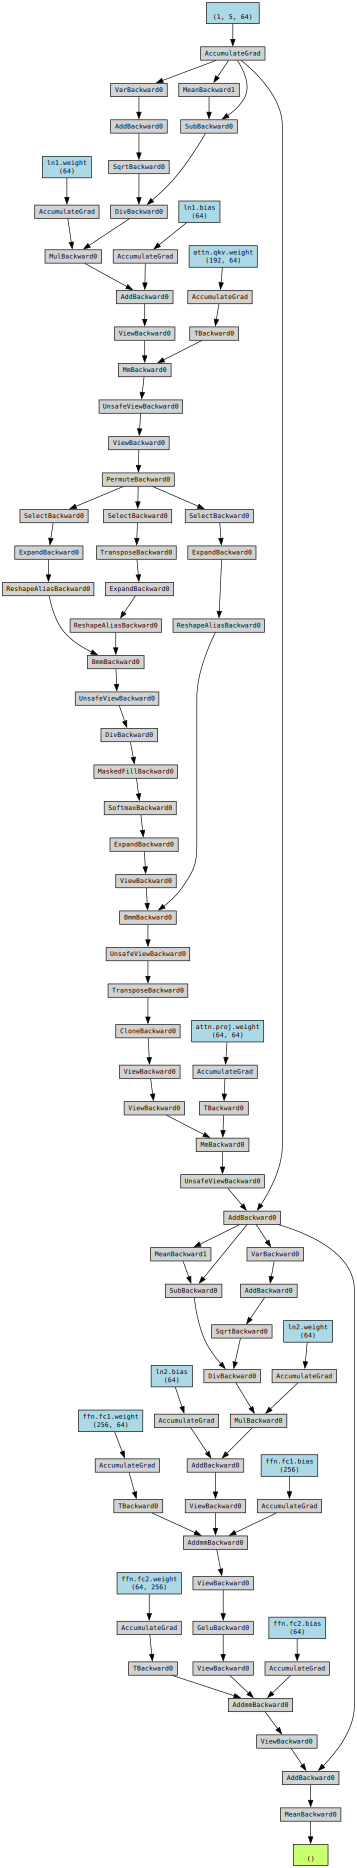

In [15]:
# draw the computational graph of a forward pass through the block
# run: winget install Graphviz.Graphviz
from IPython.display import display, Image, SVG
from torchviz import make_dot
import torch

x = torch.randn(1, 5, 64, requires_grad=True)
block = TransformerBlock(d_model=64, n_heads=8, dropout=0.0)
y = block(x)

dot = make_dot(y.mean(), params=dict(block.named_parameters()))
# Fallback: save and show as PNG
#dot.graph_attr.update(dpi="300")
dot.format = "svg"
dot.render("transformer_block_graph", cleanup=True)
display(SVG("images/transformer_block_graph.svg"))